# <span style="color:rgb(213,80,0)">Example using generic control input</span>

We use a generic control input, as described in [json schema documentation](https://github.com/BattMoTeam/BattMo/blob/main/Utilities/JsonSchemas/GenericControl.schema.json).

## Input setup

We load material parameter input parameters


In [1]:
jsonstruct_material = parseBattmoJson(fullfile('ParameterData', ...
                                               'BatteryCellParameters', ...
                                               'LithiumIonBatteryCell', ...
                                               'lithium_ion_battery_lco_graphite.json'));


We load geometry parameter input parameters


In [2]:
jsonstruct_geometry = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'geometryChen.json'));


We load the generic control parameter we want to use


In [3]:
jsonstruct_control  = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'generic_step_control_simple_example.json'));


We print it to command window


In [4]:
viewStruct(jsonstruct_control)

{
  "Control": {
    "controlPolicy": "Generic",
    "controlsteps": [
      {
        "controltype": "rest",
        "termination": {
          "quantity": "time",
          "value": 4000
        },
        "timeStepSize": 600
      },
      {
        "controltype": "current",
        "value": 1,
        "direction": "discharge",
        "termination": {
          "quantity": "voltage",
          "value": 3,
          "comparison": "below"
        },
        "timeStepSize": 600
      },
      {
        "controltype": "voltage",
        "value": 3,
        "termination": {
          "value": 0.0001,
          "quantity": "current",
          "comparison": "absolute value below"
        },
        "timeStepSize": 600
      },
      {
        "controltype": "current",
        "value": 1,
        "direction": "charge",
        "termination": {
          "quantity": "voltage",
          "value": 4,
          "comparison": "above"
        },
        "timeStepSize": 600
      },
      {
    


We remove the fields that are not relevant for this example. This is done to simplify the input parameters and focus on the relevant aspects of the model.


In [5]:
jsonstruct_material = removeStructFields(jsonstruct_material              , ...
                                             {'Control', 'DRate'}             , ...
                                             {'Control', 'controlPolicy'}     , ...
                                             {'Control', 'upperCutoffVoltage'}, ...
                                             {'Control', 'rampupTime'}        , ...
                                             {'Control', 'lowerCutoffVoltage'});


We merge all the input structures


In [6]:
jsonstruct = mergeStructs({jsonstruct_material, ...
                               jsonstruct_geometry, ...
                               jsonstruct_control});


We do not include thermal effects and the current collectors in this example to simplify the model.


In [7]:
jsonstruct.use_thermal = false;
jsonstruct.include_current_collectors = false;


We run the simulation


In [8]:
output = runBattery(jsonstruct);


## Plotting


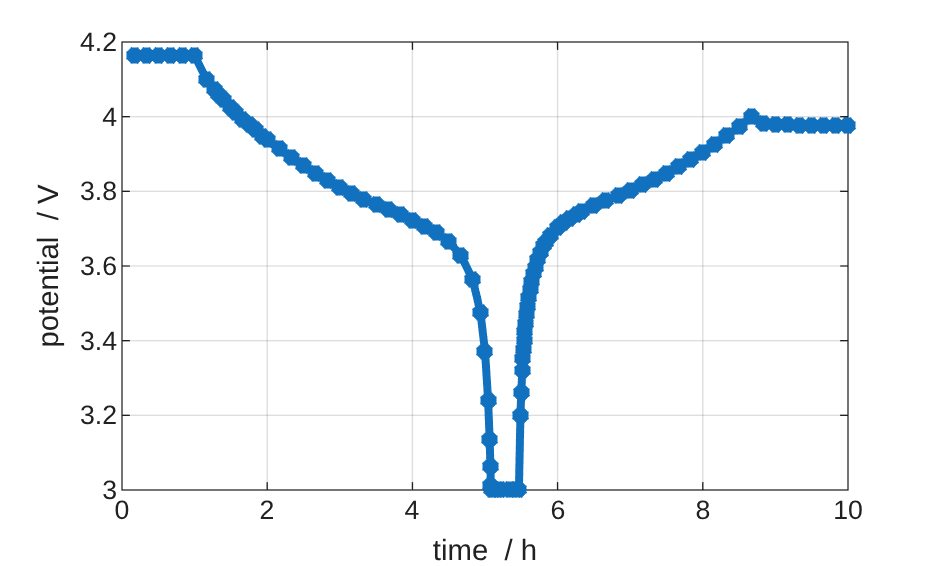

In [9]:
states = output.states;


E = cellfun(@(x) x.Control.E, states);
I = cellfun(@(x) x.Control.I, states);
time = cellfun(@(x) x.time, states);


figure
plot(time/hour, E, '*-', 'linewidth', 3);
grid on
xlabel 'time  / h';
ylabel 'potential  / V';


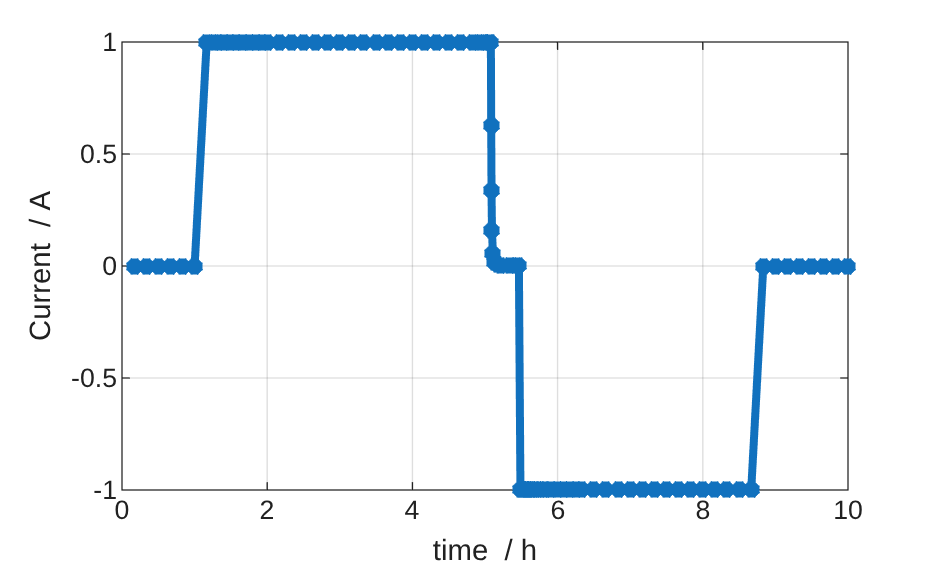

In [10]:


figure
plot(time/hour, I, '*-', 'linewidth', 3);
grid on
xlabel 'time  / h';
ylabel 'Current  / A';

In [11]:


%{
Copyright 2021-2026 SINTEF Industry, Sustainable Energy Technology
and SINTEF Digital, Mathematics & Cybernetics.


This file is part of The Battery Modeling Toolbox BattMo


BattMo is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.


BattMo is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.


You should have received a copy of the GNU General Public License
along with BattMo.  If not, see <http://www.gnu.org/licenses/>.
%}